# Lizard prediction - betere Kaggle submission volgens de PowerPoints

Deze notebook volgt de aanpak uit de lessen:

1. Afbeeldingen en labels inladen
2. Data verkennen
3. Train/validatie split maken
4. Data augmentation gebruiken tegen overfitting
5. Transfer learning met een pretrained CNN
6. Fine-tuning toepassen
7. Model evalueren met accuracy, classification report en confusion matrix
8. `submission.csv` maken voor Kaggle

De belangrijkste verbetering tegenover een eigen CNN is **transfer learning**: we starten van een model dat al visuele kenmerken geleerd heeft op ImageNet en trainen daarboven een nieuwe classificatielaag voor de 7 hagedisklassen.

In [2]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU's:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1778490773.804960   14665 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778490773.878625   14665 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778490775.086683   14665 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU's: []


W0000 00:00:1778490775.717332   14665 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
BASE_DIR = Path("lizard-prediction-thomas-more")
TRAIN_DIR = BASE_DIR / "train"
TEST_DIR = BASE_DIR / "test"
TRAIN_CSV = BASE_DIR / "train.csv"
TEST_CSV = BASE_DIR / "test.csv"
SAMPLE_SUB = BASE_DIR / "sample_submission.csv"

CLASS_NAMES = [
    "Black_spiny-tailed_iguana",
    "Brown_anole",
    "Cuban_knight_anole",
    "Desert_iguana",
    "Green_anole",
    "Green_iguana",
    "Lesser_Antillean_iguana",
]

NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = (260, 260)
BATCH_SIZE = 16

# EfficientNetV2S is haalbaar op de meeste laptops. Voor meer score op GPU kan je V2M proberen.
BACKBONE = "EfficientNetV2S"  # opties: EfficientNetV2S, EfficientNetV2M
MODEL_PATH = f"best_{BACKBONE.lower()}_pwp.keras"

print("Aantal klassen:", NUM_CLASSES)
print("Image size:", IMG_SIZE)
print("Backbone:", BACKBONE)

Aantal klassen: 7
Image size: (260, 260)
Backbone: EfficientNetV2S


## 1. Data inladen

`train.csv` bevat de bestandsnaam en het label. De afbeeldingen staan in submappen per klasse. Omdat sommige mapnamen `_` gebruiken waar de bestandsnamen `-` gebruiken, zoeken we de bestanden robuust op.

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(train_df.shape)
display(train_df.head())
print(test_df.shape)
display(test_df.head())

(1334, 2)


,id,label
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
1,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
2,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
3,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
4,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0


(326, 1)


,id
0,1
1,2
2,3
3,4
4,5


In [5]:
def find_train_image(row):
    filename = row["id"]
    label = int(row["label"])

    # Eerst zoeken in de verwachte klassendirectory.
    expected_dir = TRAIN_DIR / CLASS_NAMES[label].replace("-", "_")
    candidate = expected_dir / filename
    if candidate.exists():
        return str(candidate)

    # Fallback: zoek in alle train-submappen.
    for subdir in TRAIN_DIR.iterdir():
        candidate = subdir / filename
        if candidate.exists():
            return str(candidate)

    return None


def find_test_image(image_id):
    for ext in [".jpg", ".jpeg", ".png"]:
        candidate = TEST_DIR / f"{image_id}{ext}"
        if candidate.exists():
            return str(candidate)
    return None

train_df["filepath"] = train_df.apply(find_train_image, axis=1)
test_df["filepath"] = test_df["id"].apply(find_test_image)

print("Ontbrekende train images:", train_df["filepath"].isna().sum())
print("Ontbrekende test images:", test_df["filepath"].isna().sum())
assert train_df["filepath"].notna().all()
assert test_df["filepath"].notna().all()

Ontbrekende train images: 0
Ontbrekende test images: 0


## 2. Data verkennen

Dit sluit aan bij de PowerPoint-stap waarin je eerst kijkt naar de verdeling van de klassen en voorbeelden van de afbeeldingen.

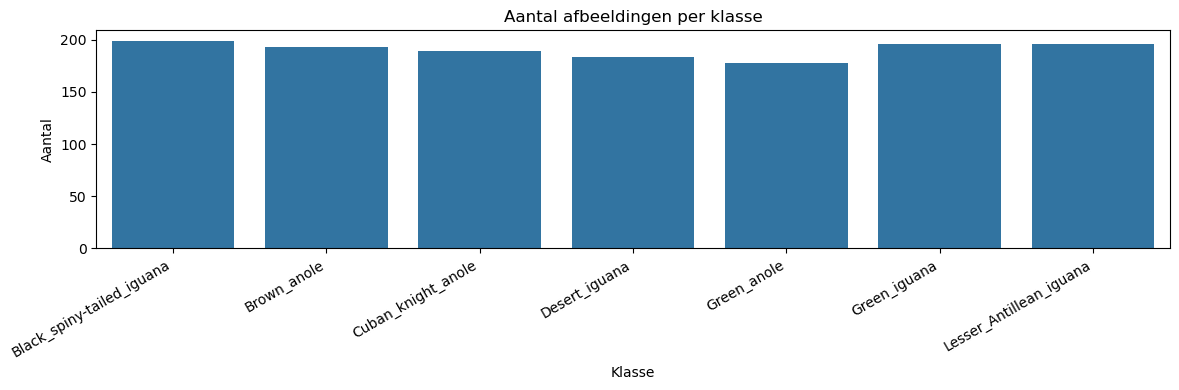

label
0    199
1    193
2    189
3    183
4    178
5    196
6    196
Name: count, dtype: int64


In [6]:
label_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
sns.barplot(x=[CLASS_NAMES[i] for i in label_counts.index], y=label_counts.values)
plt.xticks(rotation=30, ha="right")
plt.title("Aantal afbeeldingen per klasse")
plt.ylabel("Aantal")
plt.xlabel("Klasse")
plt.tight_layout()
plt.show()

print(label_counts)

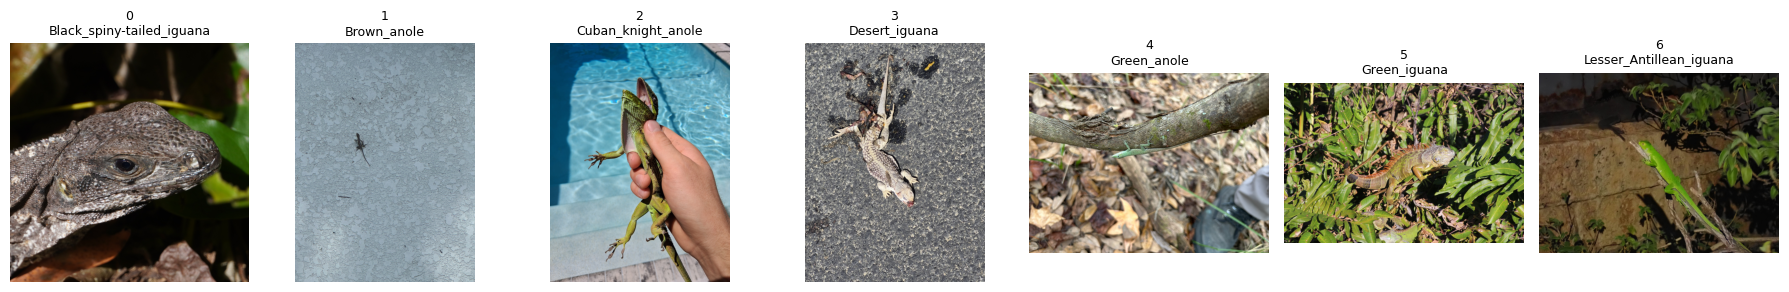

In [7]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 3))
for label in range(NUM_CLASSES):
    sample = train_df[train_df["label"] == label].sample(1, random_state=SEED).iloc[0]
    img = Image.open(sample["filepath"])
    axes[label].imshow(img)
    axes[label].set_title(f"{label}\n{CLASS_NAMES[label]}", fontsize=9)
    axes[label].axis("off")
plt.tight_layout()
plt.show()

## 3. Train/validatie split

We gebruiken een **stratified split**, zodat elke klasse ongeveer dezelfde verhouding behoudt in training en validatie.

In [8]:
train_split, val_split = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=SEED,
)

print("Train:", len(train_split))
print("Validatie:", len(val_split))
print("Validatie verdeling:")
print(val_split["label"].value_counts().sort_index())

Train: 1067
Validatie: 267
Validatie verdeling:
label
0    40
1    39
2    38
3    37
4    35
5    39
6    39
Name: count, dtype: int64


In [9]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_split["label"].values,
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}
class_weights

{0: 0.958670260557053,
 1: 0.9897959183673469,
 2: 1.009460737937559,
 3: 1.044031311154599,
 4: 1.065934065934066,
 5: 0.9708826205641492,
 6: 0.9708826205641492}

## 4. Dataset pipeline en data augmentation

Volgens de PowerPoints helpt data augmentation tegen overfitting, zeker bij een kleine image dataset. We houden de transformaties realistisch: horizontaal spiegelen, kleine rotatie, zoom, contrast en helderheid.

EfficientNetV2 krijgt `include_preprocessing=True`, dus de input blijft raw RGB in `[0, 255]`.

In [10]:
def load_image(filepath, label=None):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, IMG_SIZE)

    if label is None:
        return image

    label = tf.one_hot(label, NUM_CLASSES)
    return image, label


def make_dataset(df, training=False):
    paths = df["filepath"].tolist()
    labels = df["label"].astype(int).tolist()
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_split, training=True)
val_ds = make_dataset(val_split, training=False)

print("Datasets klaar")

Datasets klaar


In [11]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomContrast(0.15),
    ],
    name="data_augmentation",
)

## 5. Transfer learning model

Dit is de kern uit de PowerPoints over transfer learning:

- laad een pretrained CNN zonder originele top-laag;
- freeze de backbone in fase 1;
- train een nieuwe classificatiekop;
- unfreeze later een beperkt aantal laatste lagen voor fine-tuning.

In [12]:
def get_backbone(name):
    if name == "EfficientNetV2S":
        return keras.applications.EfficientNetV2S
    if name == "EfficientNetV2M":
        return keras.applications.EfficientNetV2M
    raise ValueError("Kies EfficientNetV2S of EfficientNetV2M")

BackboneClass = get_backbone(BACKBONE)
base_model = BackboneClass(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    include_preprocessing=True,
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="species")(x)

model = keras.Model(inputs, outputs, name="lizard_transfer_learning_pwp")
model.summary()

Model: "lizard_transfer_learning_pwp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 9, 9, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ species (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,997,991 (80.10 MB)

 Trainable params: 663,047 (2.53 MB)

 Non-trainable params: 20,334,944 (77.57 MB)

## 6. Fase 1: classificatiekop trainen

De pretrained lagen blijven bevroren. Alleen de nieuwe Dense-lagen leren nu de 7 hagedisklassen.

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=8e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

callbacks_phase1 = [
    EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.4, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("phase1_" + MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
]

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks_phase1,
)

Epoch 1/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - accuracy: 0.3491 - loss: 2.2470
Epoch 1: val_accuracy improved from None to 0.59925, saving model to phase1_best_efficientnetv2s_pwp.keras

Epoch 1: finished saving model to phase1_best_efficientnetv2s_pwp.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 75s 923ms/step - accuracy: 0.4049 - loss: 2.1542 - val_accuracy: 0.5993 - val_loss: 1.3044 - learning_rate: 8.0000e-04
Epoch 2/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.5174 - loss: 1.6964
Epoch 2: val_accuracy improved from 0.59925 to 0.64045, saving model to phase1_best_efficientnetv2s_pwp.keras

Epoch 2: finished saving model to phase1_best_efficientnetv2s_pwp.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 57s 839ms/step - accuracy: 0.5314 - loss: 1.6335 - val_accuracy: 0.6404 - val_loss: 1.2005 - learning_rate: 8.0000e-04
Epoch 3/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.6058 - loss: 1.4073
Epoch 3: val_accuracy improved from 0.64045 to 0.67790, saving model to phase1_best_eff

KeyboardInterrupt: 

## 7. Fase 2: fine-tuning

Nu maken we alleen de laatste lagen van de backbone trainbaar. BatchNormalization-lagen blijven bevroren, omdat dat stabieler is bij kleine batches.

In [ ]:
base_model.trainable = True

fine_tune_last_n = 60 if BACKBONE == "EfficientNetV2S" else 90
for layer in base_model.layers[:-fine_tune_last_n]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_params = sum(np.prod(v.shape) for v in model.trainable_variables)
print("Fine-tune laatste lagen:", fine_tune_last_n)
print("Trainbare parameters:", f"{trainable_params:,}")

steps_per_epoch = max(1, len(train_split) // BATCH_SIZE)
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=8e-6,
    decay_steps=steps_per_epoch * 35,
    alpha=0.05,
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
    metrics=["accuracy"],
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
]

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks_phase2,
)

Fine-tune laatste lagen: 60
Trainbare parameters: 4,591,367
Epoch 1/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - accuracy: 0.7358 - loss: 0.9125
Epoch 1: val_accuracy improved from None to 0.72659, saving model to best_efficientnetv2s_pwp.keras

Epoch 1: finished saving model to best_efficientnetv2s_pwp.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.7376 - loss: 0.9193 - val_accuracy: 0.7266 - val_loss: 0.9976
Epoch 2/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.7161 - loss: 0.9364
Epoch 2: val_accuracy improved from 0.72659 to 0.73034, saving model to best_efficientnetv2s_pwp.keras

Epoch 2: finished saving model to best_efficientnetv2s_pwp.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.7385 - loss: 0.9010 - val_accuracy: 0.7303 - val_loss: 0.9924
Epoch 3/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - accuracy: 0.7360 - loss: 0.8961
Epoch 3: val_accuracy did not improve from 0.73034
67/67 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.7563 - loss:

## 8. Training curves

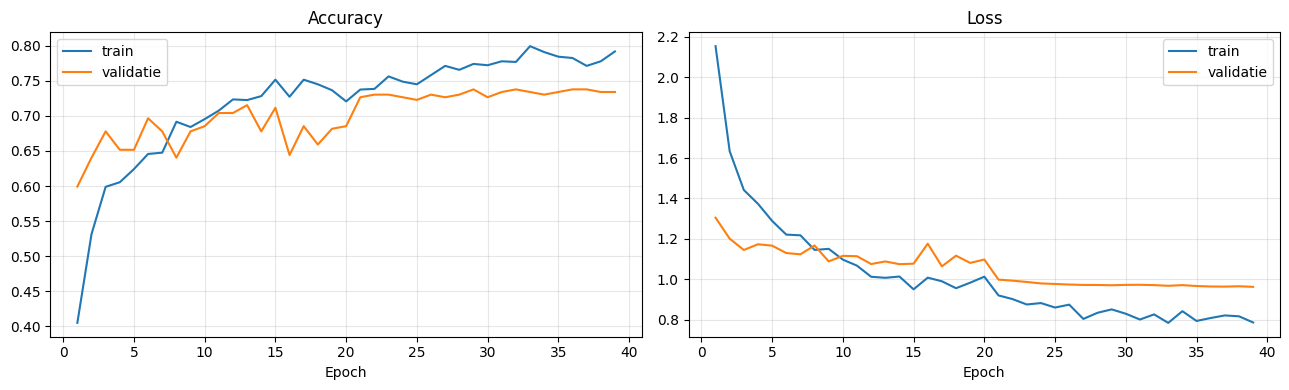

In [ ]:
def plot_history(histories):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for history in histories:
        acc += history.history.get("accuracy", [])
        val_acc += history.history.get("val_accuracy", [])
        loss += history.history.get("loss", [])
        val_loss += history.history.get("val_loss", [])

    epochs = range(1, len(acc) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, acc, label="train")
    axes[0].plot(epochs, val_acc, label="validatie")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, loss, label="train")
    axes[1].plot(epochs, val_loss, label="validatie")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history([history_phase1, history_phase2])

## 9. Evaluatie op validatieset

Hiermee toon je aan hoe goed het model generaliseert. Dit is belangrijker dan enkel training accuracy.

In [ ]:
best_model = keras.models.load_model(MODEL_PATH)
val_loss, val_acc = best_model.evaluate(val_ds, verbose=0)
print(f"Validatie accuracy: {val_acc:.4f}")
print(f"Validatie loss: {val_loss:.4f}")

Validatie accuracy: 0.7378
Validatie loss: 0.9697


17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step 
                           precision    recall  f1-score   support

Black_spiny-tailed_iguana       0.80      0.88      0.83        40
              Brown_anole       0.62      0.79      0.70        39
       Cuban_knight_anole       0.65      0.82      0.72        38
            Desert_iguana       1.00      0.89      0.94        37
              Green_anole       0.70      0.40      0.51        35
             Green_iguana       0.82      0.59      0.69        39
  Lesser_Antillean_iguana       0.68      0.77      0.72        39

                 accuracy                           0.74       267
                macro avg       0.75      0.73      0.73       267
             weighted avg       0.75      0.74      0.73       267



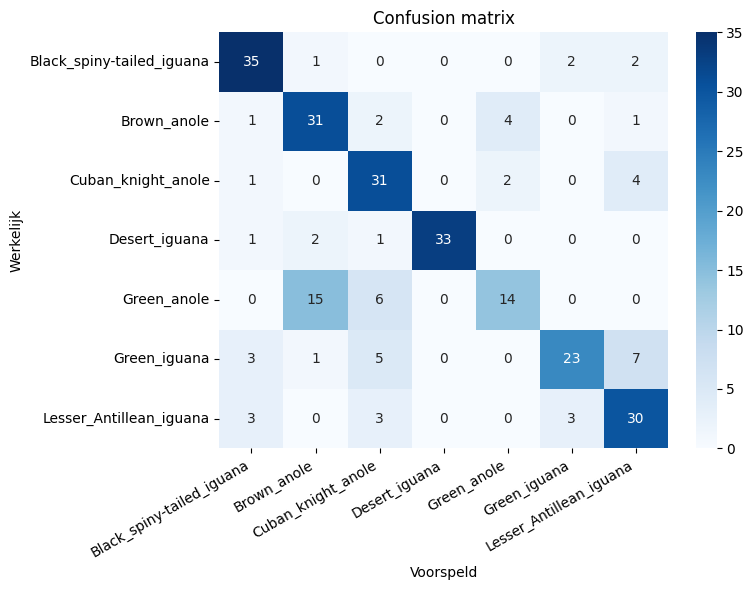

In [ ]:
val_probs = best_model.predict(val_ds, verbose=1)
y_pred = np.argmax(val_probs, axis=1)
y_true = val_split["label"].astype(int).tolist()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Voorspeld")
plt.ylabel("Werkelijk")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

## 10. Kaggle submission maken

Voor Kaggle voorspellen we op de testbeelden. We gebruiken een kleine Test Time Augmentation: voorspelling op origineel beeld + horizontaal gespiegeld beeld. Dit past bij het augmentation-principe uit de PowerPoints en kan de voorspelling stabieler maken.

In [ ]:
def make_test_dataset(filepaths, flip=False):
    ds = tf.data.Dataset.from_tensor_slices(filepaths)

    def load_test_image(path):
        image = load_image(path, label=None)
        if flip:
            image = tf.image.flip_left_right(image)
        return image

    return ds.map(load_test_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


test_paths = test_df["filepath"].tolist()
probs_original = best_model.predict(make_test_dataset(test_paths, flip=False), verbose=1)
probs_flipped = best_model.predict(make_test_dataset(test_paths, flip=True), verbose=1)

avg_probs = (probs_original + probs_flipped) / 2.0
predicted_labels = np.argmax(avg_probs, axis=1)
confidence = np.max(avg_probs, axis=1)

print("Gemiddelde confidence:", confidence.mean())
print("Verdeling voorspellingen:")
for label, count in sorted(Counter(predicted_labels).items()):
    print(label, CLASS_NAMES[label], count)

21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 838ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 700ms/step
Gemiddelde confidence: 0.7574204
Verdeling voorspellingen:
0 Black_spiny-tailed_iguana 35
1 Brown_anole 52
2 Cuban_knight_anole 50
3 Desert_iguana 55
4 Green_anole 37
5 Green_iguana 40
6 Lesser_Antillean_iguana 57


In [ ]:
submission = pd.DataFrame({
    "id": test_df["id"].tolist(),
    "label": predicted_labels.tolist(),
})

sample_sub = pd.read_csv(SAMPLE_SUB)
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
assert submission["label"].between(0, NUM_CLASSES - 1).all()

submission.to_csv("submission.csv", index=False)
submission.to_csv("submission_pwp_beter.csv", index=False)

display(submission.head(10))
print("submission.csv en submission_pwp_beter.csv zijn opgeslagen")

,id,label
0,1,6
1,2,5
2,3,2
3,4,5
4,5,0
5,6,4
6,7,6
7,8,4
8,9,4
9,10,1


submission.csv en submission_pwp_beter.csv zijn opgeslagen


## Waarom dit volgens de PowerPoints is

- **CNN concepten:** de backbone bestaat uit convolutionele lagen die visuele patronen leren.
- **Transfer learning:** EfficientNetV2 gebruikt pretrained ImageNet-gewichten.
- **Data augmentation:** RandomFlip, RandomRotation, RandomZoom, RandomTranslation en RandomContrast verminderen overfitting.
- **Fine-tuning:** eerst trainen we alleen de nieuwe classificatiekop, daarna de laatste backbone-lagen.
- **Regularisatie:** Dropout, L2 regularisatie, label smoothing en EarlyStopping helpen tegen overfitting.
- **Evaluatie:** validatie accuracy, classification report en confusion matrix tonen de prestaties.
- **Kaggle:** de laatste cell maakt exact de gevraagde `submission.csv`.